## 1) Import Lib

In [1]:
from pathlib import Path
import warnings
import json
import sys
import platform

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import sklearn

warnings.filterwarnings("ignore")

## 2) Data

In [2]:
PROJECT_ROOT = Path(r"D:/Study/DATN/hand_gesture_windows_control")

DATA_DIR = PROJECT_ROOT.joinpath("data", "processed", "static")
MODEL_DIR = PROJECT_ROOT.joinpath("models", "checkpoints")
REPORT_DIR = PROJECT_ROOT.joinpath("models", "reports", "model_comparison_ipynb")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR.joinpath("train_static_v1.csv")
VAL_CSV = DATA_DIR.joinpath("val_static_v1.csv")
TEST_CSV = DATA_DIR.joinpath("test_static_v1.csv")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("TRAIN_CSV =", TRAIN_CSV)
print("VAL_CSV   =", VAL_CSV)
print("TEST_CSV  =", TEST_CSV)

PROJECT_ROOT = D:\Study\DATN\hand_gesture_windows_control
TRAIN_CSV = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\train_static_v1.csv
VAL_CSV   = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\val_static_v1.csv
TEST_CSV  = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\test_static_v1.csv


## 2. Load dữ liệu

In [5]:
FEATURE_COLS = [f"f{i}" for i in range(63)]

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

X_train = train_df[FEATURE_COLS].values
y_train = train_df["label"].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df["label"].values

X_test = test_df[FEATURE_COLS].values
y_test = test_df["label"].values

labels = sorted(set(y_train) | set(y_val) | set(y_test))

print("Train:", X_train.shape, len(y_train))
print("Val:  ", X_val.shape, len(y_val))
print("Test: ", X_test.shape, len(y_test))
print("Labels:", labels)

Train: (4034, 63) 4034
Val:   (505, 63) 505
Test:  (504, 63) 504
Labels: ['fist', 'no_gesture', 'open_palm', 'pinch', 'point', 'two_fingers']


In [6]:
X_train[:1]

array([[ 0.        ,  0.        ,  0.        ,  0.11623871, -0.05731544,
        -0.02834016,  0.20711586, -0.20334384, -0.0419783 ,  0.28163379,
        -0.31416559, -0.05721428,  0.35187951, -0.36564514, -0.07456427,
         0.17202838, -0.44897351, -0.02169646,  0.25532782, -0.60472172,
        -0.05831634,  0.30893987, -0.70306391, -0.08933   ,  0.3527649 ,
        -0.78406703, -0.10959585,  0.11451207, -0.50160271, -0.03299256,
         0.1714998 , -0.72317231, -0.06310476,  0.21672782, -0.85347253,
        -0.08728774,  0.25108612, -0.96250099, -0.10270148,  0.05410824,
        -0.50183475, -0.04997542,  0.08584528, -0.71894217, -0.08002818,
         0.12344315, -0.84947497, -0.09951808,  0.15900216, -0.9592908 ,
        -0.11075296, -0.01214642, -0.46147814, -0.07026224,  0.00268977,
        -0.63605523, -0.09612297,  0.02888051, -0.74334449, -0.10387205,
         0.05870003, -0.83523136, -0.10718443]])

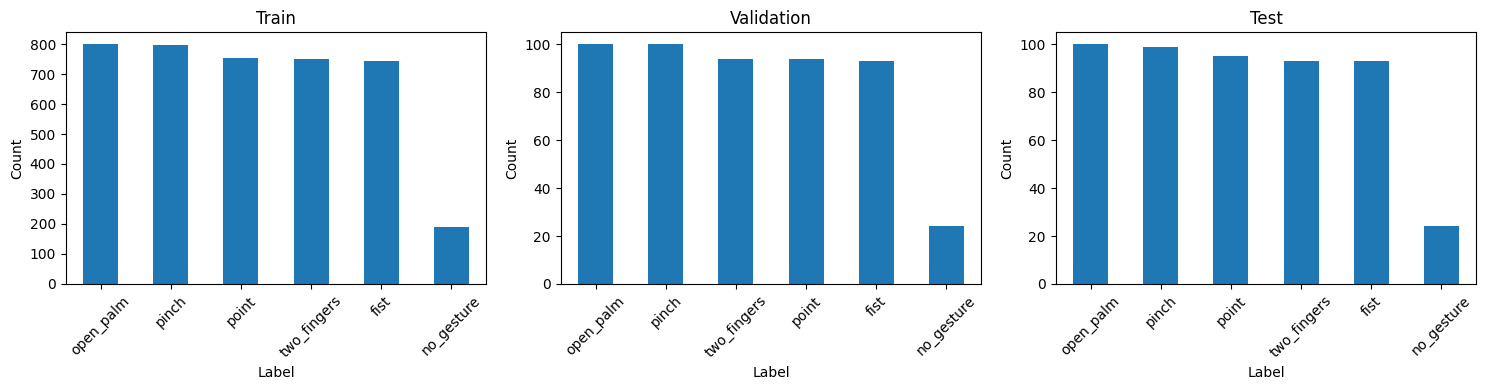

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_df["label"].value_counts().plot(kind="bar", ax=axes[0], title="Train")
val_df["label"].value_counts().plot(kind="bar", ax=axes[1], title="Validation")
test_df["label"].value_counts().plot(kind="bar", ax=axes[2], title="Test")

for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [8]:
display(train_df["label"].value_counts().rename("train_count").to_frame())
display(val_df["label"].value_counts().rename("val_count").to_frame())
display(test_df["label"].value_counts().rename("test_count").to_frame())

,train_count
label,
open_palm,799
pinch,798
point,755
two_fingers,750
fist,742
no_gesture,190


,val_count
label,
open_palm,100
pinch,100
two_fingers,94
point,94
fist,93
no_gesture,24


,test_count
label,
open_palm,100
pinch,99
point,95
two_fingers,93
fist,93
no_gesture,24


## 3. Train Model (SVM, logistic reg, KNN, Random fr, mlp)

In [9]:
models = {
    "svm_rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", class_weight="balanced", probability=True))
    ]),
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "knn": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance"
        ))
    ]),
    "random_forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    # "mlp": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("clf", MLPClassifier(
    #         hidden_layer_sizes=(128, 64),
    #         activation="relu",
    #         solver="adam",
    #         alpha=1e-4,
    #         batch_size=64,
    #         learning_rate_init=1e-3,
    #         max_iter=300,
    #         early_stopping=True,
    #         validation_fraction=0.1,
    #         random_state=42
    #     ))
    # ]),
}

list(models.keys())

['svm_rbf', 'logistic_regression', 'knn', 'random_forest']

In [10]:
# hàm đánh giá model

def evaluate_model(model_name, model, X_val, y_val, X_test, y_test, labels):
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    val_macro_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    val_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    val_report = classification_report(
        y_val, y_val_pred, labels=labels, digits=4, zero_division=0
    )
    test_report = classification_report(
        y_test, y_test_pred, labels=labels, digits=4, zero_division=0
    )

    val_cm = confusion_matrix(y_val, y_val_pred, labels=labels)
    test_cm = confusion_matrix(y_test, y_test_pred, labels=labels)

    return {
        "model_name": model_name,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_macro_f1": val_macro_f1,
        "test_macro_f1": test_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "test_weighted_f1": test_weighted_f1,
        "val_report": val_report,
        "test_report": test_report,
        "val_cm": val_cm,
        "test_cm": test_cm,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
    }

In [11]:
results = {}
summary_rows = []

for model_name, model in models.items():
    print("=" * 80)
    print("Training:", model_name)

    model.fit(X_train, y_train)

    result = evaluate_model(
        model_name=model_name,
        model=model,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        labels=labels,
    )

    results[model_name] = {
        "model": model,
        **result
    }

    summary_rows.append({
        "model": model_name,
        "val_accuracy": round(result["val_acc"], 6),
        "test_accuracy": round(result["test_acc"], 6),
        "val_macro_f1": round(result["val_macro_f1"], 6),
        "test_macro_f1": round(result["test_macro_f1"], 6),
        "val_weighted_f1": round(result["val_weighted_f1"], 6),
        "test_weighted_f1": round(result["test_weighted_f1"], 6),
    })

    print("Validation Accuracy :", round(result["val_acc"], 4))
    print("Test Accuracy       :", round(result["test_acc"], 4))
    print("Validation Macro F1 :", round(result["val_macro_f1"], 4))
    print("Test Macro F1       :", round(result["test_macro_f1"], 4))

Training: svm_rbf
Validation Accuracy : 0.9782
Test Accuracy       : 0.9702
Validation Macro F1 : 0.9707
Test Macro F1       : 0.9608
Training: logistic_regression
Validation Accuracy : 0.9703
Test Accuracy       : 0.9782
Validation Macro F1 : 0.9688
Test Macro F1       : 0.9716
Training: knn
Validation Accuracy : 0.9861
Test Accuracy       : 0.9821
Validation Macro F1 : 0.9773
Test Macro F1       : 0.9722
Training: random_forest
Validation Accuracy : 0.9861
Test Accuracy       : 0.9782
Validation Macro F1 : 0.9773
Test Macro F1       : 0.9687


## 4. Kết quả train

In [12]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["test_macro_f1", "val_macro_f1", "test_accuracy", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

summary_df

,model,val_accuracy,test_accuracy,val_macro_f1,test_macro_f1,val_weighted_f1,test_weighted_f1
0,knn,0.986139,0.982143,0.977280,0.972248,0.986171,0.982356
1,logistic_regression,0.970297,0.978175,0.968835,0.971588,0.970188,0.978420
2,random_forest,0.986139,0.978175,0.977280,0.968742,0.986171,0.978453
3,svm_rbf,0.978218,0.970238,0.970725,0.960767,0.978244,0.970752


In [13]:
best_row = summary_df.iloc[0]
BEST_MODEL_NAME = best_row["model"]

print("=== BEST MODEL ===")
print(best_row)
print("\nChosen model:", BEST_MODEL_NAME)

=== BEST MODEL ===
model                    knn
val_accuracy        0.986139
test_accuracy       0.982143
val_macro_f1         0.97728
test_macro_f1       0.972248
val_weighted_f1     0.986171
test_weighted_f1    0.982356
Name: 0, dtype: object

Chosen model: knn


In [14]:
summary_csv_path = REPORT_DIR.joinpath("model_comparison_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)
print("Model comparison summary saved to:", summary_csv_path)

Model comparison summary saved to: D:\Study\DATN\hand_gesture_windows_control\models\reports\model_comparison_ipynb\model_comparison_summary.csv


## 5. Classification report từng model

### 5.1) SVM RBF

In [15]:
def classification_report(model_name):
    print("[VALIDATION REPORT]")
    print(results[model_name]["val_report"])

    print("[TEST REPORT]")
    print(results[model_name]["test_report"])

def confusion_matrix(model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["val_cm"],
        display_labels=labels
    ).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{model_name} - Validation")

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["test_cm"],
        display_labels=labels
    ).plot(ax=axes[1], xticks_rotation=45, colorbar=False)
    axes[1].set_title(f"{model_name} - Test")

    plt.tight_layout()
    plt.show()

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9684    0.9892    0.9787        93
  no_gesture     0.9167    0.9167    0.9167        24
   open_palm     0.9519    0.9900    0.9706       100
       pinch     1.0000    0.9500    0.9744       100
       point     1.0000    0.9894    0.9947        94
 two_fingers     0.9894    0.9894    0.9894        94

    accuracy                         0.9782       505
   macro avg     0.9711    0.9708    0.9707       505
weighted avg     0.9787    0.9782    0.9782       505

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9783    0.9677    0.9730        93
  no_gesture     0.8000    1.0000    0.8889        24
   open_palm     0.9423    0.9800    0.9608       100
       pinch     1.0000    0.9293    0.9634        99
       point     0.9895    0.9895    0.9895        95
 two_fingers     1.0000    0.9785    0.9891        93

    accuracy                         0.9702

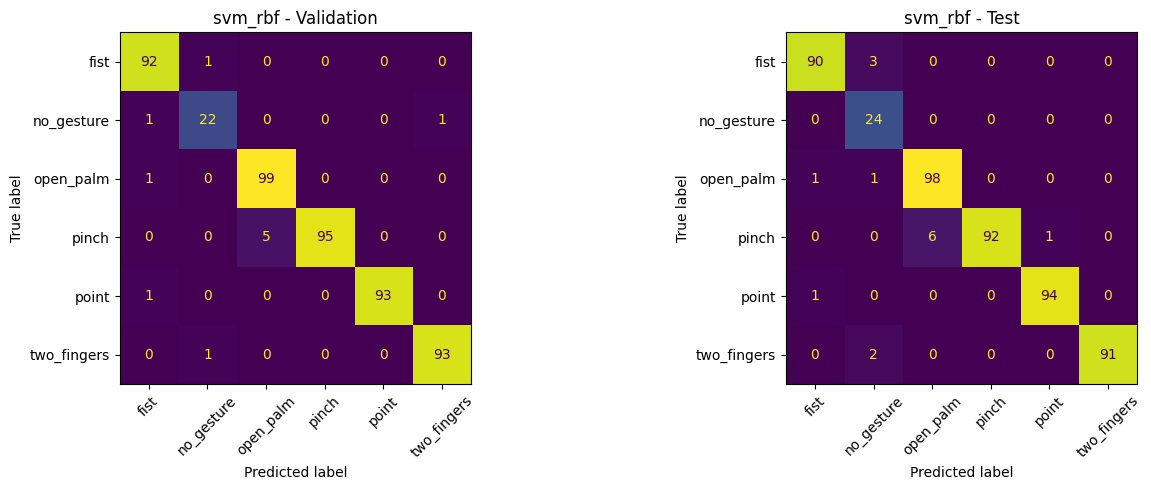

In [16]:
classification_report("svm_rbf")
confusion_matrix("svm_rbf")

### 5.2) Model logistic_regression

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9684    0.9892    0.9787        93
  no_gesture     1.0000    0.9167    0.9565        24
   open_palm     0.9417    0.9700    0.9557       100
       pinch     0.9789    0.9300    0.9538       100
       point     0.9789    0.9894    0.9841        94
 two_fingers     0.9789    0.9894    0.9841        94

    accuracy                         0.9703       505
   macro avg     0.9745    0.9641    0.9688       505
weighted avg     0.9706    0.9703    0.9702       505

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9681    0.9785    0.9733        93
  no_gesture     0.8571    1.0000    0.9231        24
   open_palm     0.9798    0.9700    0.9749       100
       pinch     0.9897    0.9697    0.9796        99
       point     0.9894    0.9789    0.9841        95
 two_fingers     1.0000    0.9892    0.9946        93

    accuracy                         0.9782

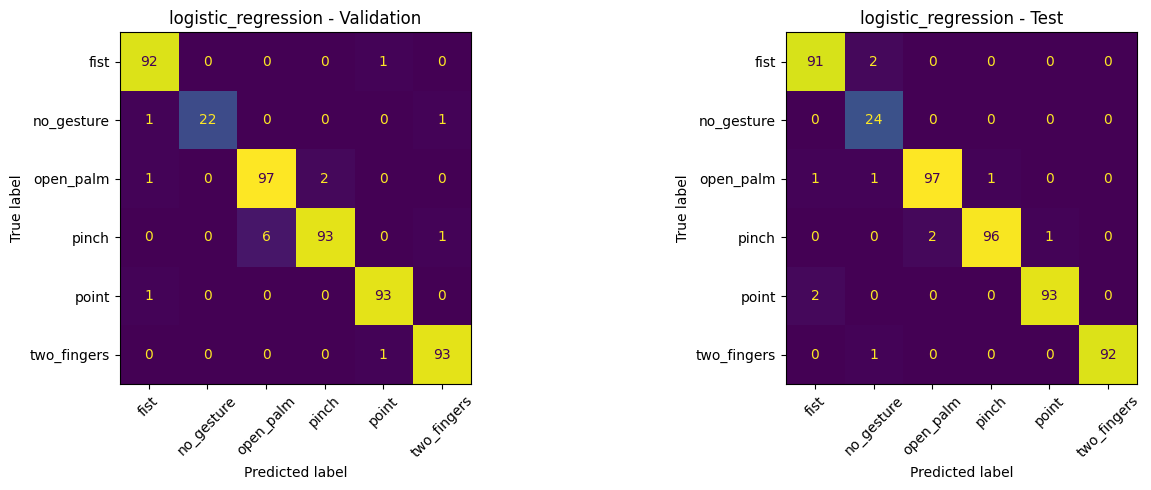

In [17]:
classification_report("logistic_regression")
confusion_matrix("logistic_regression")

### 5.3) Model KNN

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9681    0.9785    0.9733        93
  no_gesture     0.9167    0.9167    0.9167        24
   open_palm     1.0000    0.9900    0.9950       100
       pinch     1.0000    1.0000    1.0000       100
       point     1.0000    0.9894    0.9947        94
 two_fingers     0.9789    0.9894    0.9841        94

    accuracy                         0.9861       505
   macro avg     0.9773    0.9773    0.9773       505
weighted avg     0.9862    0.9861    0.9862       505

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9890    0.9677    0.9783        93
  no_gesture     0.8519    0.9583    0.9020        24
   open_palm     0.9898    0.9700    0.9798       100
       pinch     0.9900    1.0000    0.9950        99
       point     1.0000    1.0000    1.0000        95
 two_fingers     0.9785    0.9785    0.9785        93

    accuracy                         0.9821

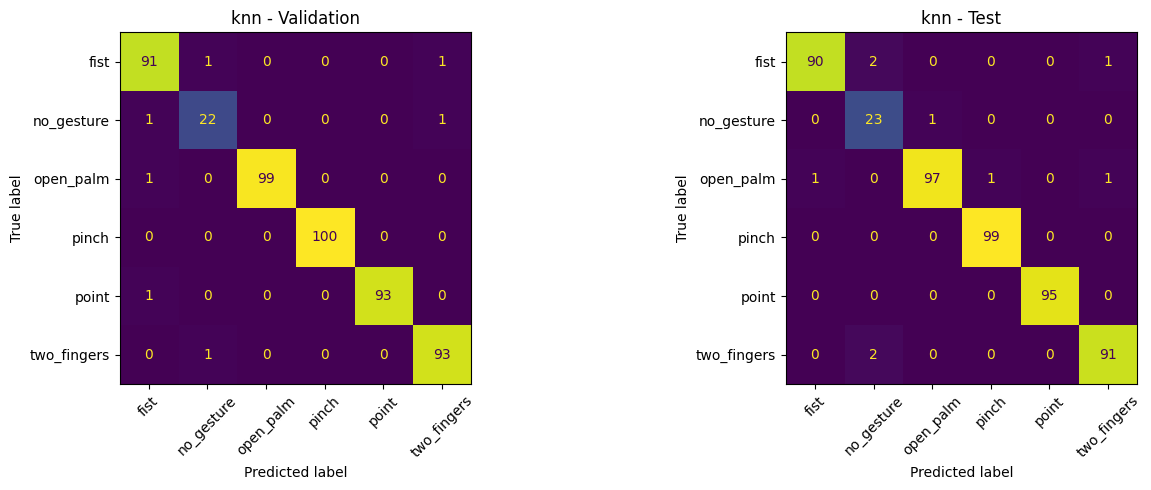

In [18]:
classification_report("knn")
confusion_matrix("knn")

### 5.4) Model random forest

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9681    0.9785    0.9733        93
  no_gesture     0.9167    0.9167    0.9167        24
   open_palm     1.0000    0.9900    0.9950       100
       pinch     1.0000    1.0000    1.0000       100
       point     1.0000    0.9894    0.9947        94
 two_fingers     0.9789    0.9894    0.9841        94

    accuracy                         0.9861       505
   macro avg     0.9773    0.9773    0.9773       505
weighted avg     0.9862    0.9861    0.9862       505

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9574    0.9677    0.9626        93
  no_gesture     0.8519    0.9583    0.9020        24
   open_palm     0.9898    0.9700    0.9798       100
       pinch     1.0000    0.9899    0.9949        99
       point     1.0000    0.9895    0.9947        95
 two_fingers     0.9785    0.9785    0.9785        93

    accuracy                         0.9782

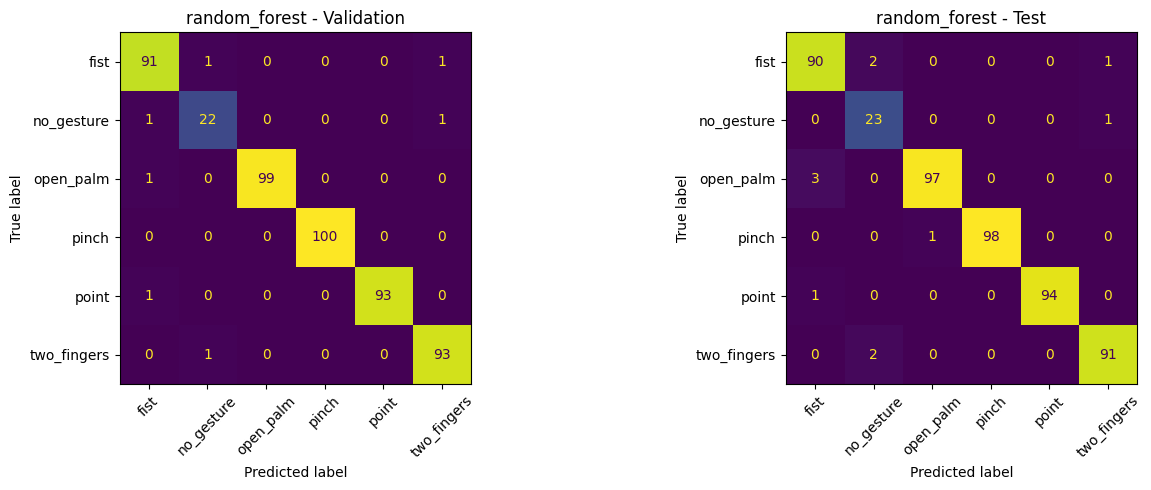

In [19]:
classification_report("random_forest")
confusion_matrix("random_forest")

## 6. Lưu model và báo cáo

In [20]:

print(labels)

['fist', 'no_gesture', 'open_palm', 'pinch', 'point', 'two_fingers']


In [21]:
BEST_MODEL_NAME = summary_df.iloc[0]["model"]

BEST_MODEL_PATH = MODEL_DIR / "static_best_model.joblib"
BEST_META_PATH = MODEL_DIR / "static_best_model_meta.json"

best_model = results[BEST_MODEL_NAME]["model"]

joblib.dump(best_model, BEST_MODEL_PATH)

meta = {
    "best_model": BEST_MODEL_NAME,
    "labels": labels,
    "feature_columns": FEATURE_COLS,
    "feature_dim": len(FEATURE_COLS),
    "val_accuracy": float(results[BEST_MODEL_NAME]["val_acc"]),
    "test_accuracy": float(results[BEST_MODEL_NAME]["test_acc"]),
    "val_macro_f1": float(results[BEST_MODEL_NAME]["val_macro_f1"]),
    "test_macro_f1": float(results[BEST_MODEL_NAME]["test_macro_f1"]),
    "data_files": {
        "train_csv": str(TRAIN_CSV),
        "val_csv": str(VAL_CSV),
        "test_csv": str(TEST_CSV),
    },
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "sklearn": sklearn.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
    "note": "Best model chosen by highest test_macro_f1, then val_macro_f1, then accuracy."
}

BEST_META_PATH.write_text(
    json.dumps(meta, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Saved model to:", BEST_MODEL_PATH)
print("Saved metadata to:", BEST_META_PATH)
print("Best model name:", BEST_MODEL_NAME)

Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_best_model.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_best_model_meta.json
Best model name: knn


In [ ]:
# # Save best final model for deployment
# BEST_MODEL_NAME = 'svm_rbf'
# BEST_MODEL_PATH = PROJECT_ROOT / 'models' / 'checkpoints'/ 'static_svm_rbf.joblib'
# BEST_META_PATH = PROJECT_ROOT / 'models' / 'reports' / 'static_svm_rbf_meta.json'

# best_model = results[BEST_MODEL_NAME]['model']

# import joblib
# joblib.dump(best_model, BEST_MODEL_PATH)

# import json
# meta = {
#     'best_model': BEST_MODEL_NAME,
#     'labels': labels,
#     'val_accuracy': float(results[BEST_MODEL_NAME]['val_acc']),
#     'test_accuracy': float(results[BEST_MODEL_NAME]['test_acc']),
#     'feature_columns': FEATURE_COLS,
#     'note': 'Chosen by highest test accuracy and better generalization than logistic_regression'
# }

# BEST_META_PATH.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

# print('Saved model to:', BEST_MODEL_PATH)
# print('Saved metadata to:', BEST_META_PATH)

Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_svm_rbf.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\reports\static_svm_rbf_meta.json
